<h1 align="center" style="font-size:60px;color:blue;">🧩 DEBI Sales Prediction & Analysis Project</h1>

<p align="center" style="font-size:20px;">
Training project during internship at 
<b style="color:blue;">🏢 DEBI</b><br>
Exploring, analyzing, and predicting sales performance using Machine Learning
</p>

<p align="center" style="font-size:18px;color:blue;">
👨‍💻 Team Members:<br>
<b>Abdelrahman Osama Mohamed Ali</b><br>
<b>Yousit Salah Muhammad Abu Al-Maati</b><br>
<b>Asmaa Ali Abdelaaty Mahmoud</b><br>
<b>Esraa Taha Abdelhasseb Ahmed</b><br>
<b>Aml Abdullah Shehata Zaytoun</b><br>
<b>Hanan Hamdy Mostafa Elabd</b>
</p>


# <p style="font-family:newtimeroman;font-size:130%;text-align:center;color:blue;"> Data Preparation</p>

# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read Data

In [2]:
# data = pd.read_csv(r"C:\Users\elfares center net\Downloads\merged.csv")
data = pd.read_csv(r"../PreparedData/mergedTrain.csv" , parse_dates=["Date"])
data

C:\Users\Yousif\AppData\Local\Temp\ipykernel_17260\4261784464.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(r"../PreparedData/mergedTrain.csv" , parse_dates=["Date"])


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


- **Copy data**

In [3]:
df = data.copy()

# Data Understanding 

# 📊 Data Understanding — Sales Dataset (Detailed)

| Column Name | Detailed Description | Data Type | Example Values | Missing Values? | Role | Preprocessing & Analytical Notes |
|--------------|----------------------|------------|----------------|-----------------|------|----------------------------------|
| **Store** | Unique ID representing each store. Used to distinguish different stores and can be used for grouping or encoding. | Integer / Categorical | 1, 2, 3, ... | No | Identifier | Not used directly for prediction unless encoded. Useful for grouping (average sales per store) or target encoding. |
| **DayOfWeek** | Represents the day of the week (1 = Monday, ..., 7 = Sunday). Captures weekly sales patterns. | Integer (1–7) | 1, 5, 7 | No | Feature | Convert to categorical or cyclical features using sin/cos transformations. Visualize average sales per day of week to detect weekly trends. |
| **Date** | The actual calendar date of the record. Used to extract time-related features (year, month, week, etc.). | String → Datetime | 2015-07-31 | No | Feature | Convert to datetime. Extract features such as year, month, day, weekofyear, and weekday. Useful for time series trend analysis. |
| **Sales** | Total daily sales for each store — often the **target variable** in forecasting tasks. | Numeric (Int/Float) | 5263, 13995 | No | **Target** | Check distribution (may require log transform). Sales are typically zero when the store is closed (Open=0). Remove closed days when training predictive models if needed. |
| **Customers** | Number of customers who visited the store that day. Strongly correlated with sales. | Integer | 555, 625, 1498 | No | Feature | Plot `Sales vs Customers` to verify correlation. Be careful using this feature if predicting future sales, since future customer counts may not be known. |
| **Open** | Indicates whether the store was open (1) or closed (0). | Binary (0/1) | 1, 0 | No | Feature / Filter | Use as a filter — most models exclude closed days (Sales=0). Or include as a feature so the model learns zero-sales behavior. |
| **Promo** | Whether a short-term promotion was active on that day. | Binary (0/1) | 1, 0 | No | Feature | Promotions usually boost sales; visualize average sales during promo vs. non-promo days. |
| **StateHoliday** | Indicates a state-level public holiday. Encoded as: “0” = None, “a” = Public holiday, “b” = Easter, “c” = Christmas. | Categorical (Object) | "0", "a", "b", "c" | No | Feature | Encode with label/one-hot encoding. Analyze sales changes during holidays vs. normal days. |
| **SchoolHoliday** | Indicates if the (store’s region) school was closed. | Binary (0/1) | 1, 0 | No | Feature | Useful for modeling foot traffic variations — families might shop differently during school holidays. |
| **StoreType** | Type of the store (a, b, c, d). Represents business scale or layout. | Categorical | "a", "b", "c", "d" | No | Feature | Apply one-hot or label encoding. Compare average sales per store type. |
| **Assortment** | Type of product assortment: “a” = basic, “b” = extra, “c” = extended. | Categorical | "a", "b", "c" | No | Feature | Encode categorically. Analyze sales differences across assortment types. |
| **CompetitionDistance** | Distance to the nearest competitor store (in meters). | Numeric (Float) | 1270.0, 570.0 | Some (≈0.26%) | Feature | Fill missing with median or large placeholder. Investigate correlation between distance and sales — closer competitors may reduce sales. |
| **CompetitionOpenSinceMonth** | Month when the nearest competitor started operating. | Numeric (1–12) | 9, 11, 12 | Yes (~32%) | Feature | Missing = competitor info unknown. Combine with Year to create “competition_open_time” feature. |
| **CompetitionOpenSinceYear** | Year when the nearest competitor started operating. | Numeric (e.g. 2008, 2007) | 2008, 2007 | Yes (~32%) | Feature | Use with Month to estimate how long the competitor has been open (competition age). Missing values can be filled logically or as “unknown”. |
| **Promo2** | Whether the store is participating in a continuous (long-term) promotion campaign. | Binary (0/1) | 1, 0 | No | Feature | Check how ongoing promotions affect sales. Combine with `PromoInterval` to detect active months. |
| **Promo2SinceWeek** | Week number when continuous promotion started. | Numeric (1–52) | 13, 14 | Yes (~50%) | Feature | Combine with `Promo2SinceYear` to determine start date of continuous promo. Missing = not in Promo2 program. |
| **Promo2SinceYear** | Year when continuous promotion started. | Numeric (e.g. 2010, 2011) | 2010, 2011 | Yes (~50%) | Feature | Missing if store not part of Promo2. Convert with `Promo2SinceWeek` into actual start date if needed. |
| **PromoInterval** | Months when Promo2 is repeated (e.g., “Jan,Apr,Jul,Oct”). | Categorical (Object) | “Jan,Apr,Jul,Oct” | Yes (~50%) | Feature | Parse months into binary indicators for whether the current month is within a promo period. |

---

### 🧩 Summary
- **Rows:** 1,017,209  
- **Columns:** 18  
- **Goal:** Understand and predict store sales based on time, promotions, holidays, and competition.  
- **Key Targets:** `Sales`  
- **Key Features:** `Customers`, `Promo`, `StoreType`, `Assortment`, `CompetitionDistance`, and time-ba
otebook or report more organized?


# <p style="font-family:newtimeroman;font-size:120%;text-align:center;color:blue;">EDA</p>

In [4]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [5]:
df.sample(5)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
790540,791,2,2013-07-23,5255,638,1,0,0,1,a,a,5950.0,4.0,2007.0,0,NaN,NaN,NaN
668216,2,6,2013-11-09,3145,376,1,0,0,0,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
441552,798,7,2014-06-01,0,0,0,0,0,0,a,a,9560.0,4.0,2001.0,0,NaN,NaN,NaN
629053,979,7,2013-12-15,0,0,0,0,0,0,a,c,2270.0,11.0,2005.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
125816,937,5,2015-04-10,6594,550,1,0,0,1,d,a,2810.0,NaN,NaN,1,10.0,2014.0,"Jan,Apr,Jul,Oct"


In [6]:
df.tail()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN
1017208,1115,2,2013-01-01,0,0,0,0,a,1,d,c,5350.0,NaN,NaN,1,22.0,2012.0,"Mar,Jun,Sept,Dec"


In [7]:
df.shape

(1017209, 18)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  object        
 10  Assortment                 1017209 non-null  object        
 11  CompetitionDistance        1014567 no

# **Insights**
- 1- data has 1017209 rows 18 columns
- 2- range index (0 t0 1017208) means there is no missing data
- 3- data has 5 float64 , 5 obgect and 8 int64 data type
- 4- data has nullumns
- 5- data free of duplicated

In [9]:
df.isna().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Store,1017209.0,558.429727,1.0,280.0,558.0,838.0,1115.0,321.908651
DayOfWeek,1017209.0,3.998341,1.0,2.0,4.0,6.0,7.0,1.997391
Date,1017209,2014-04-11 01:30:42.846061824,2013-01-01 00:00:00,2013-08-17 00:00:00,2014-04-02 00:00:00,2014-12-12 00:00:00,2015-07-31 00:00:00,NaN
Sales,1017209.0,5773.818972,0.0,3727.0,5744.0,7856.0,41551.0,3849.926175
Customers,1017209.0,633.145946,0.0,405.0,609.0,837.0,7388.0,464.411734
Open,1017209.0,0.830107,0.0,1.0,1.0,1.0,1.0,0.375539
Promo,1017209.0,0.381515,0.0,0.0,0.0,1.0,1.0,0.485759
SchoolHoliday,1017209.0,0.178647,0.0,0.0,0.0,0.0,1.0,0.383056
CompetitionDistance,1014567.0,5430.085652,20.0,710.0,2330.0,6890.0,75860.0,7715.3237
CompetitionOpenSinceMonth,693861.0,7.222866,1.0,4.0,8.0,10.0,12.0,3.211832


In [12]:
df.describe(include="object").T

,count,unique,top,freq
StateHoliday,1017209,5,0,592943
StoreType,1017209,4,a,551627
Assortment,1017209,3,a,537445
PromoInterval,509178,3,"Jan,Apr,Jul,Oct",293122


In [13]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Store,1017209.0,NaN,NaN,NaN,558.429727,1.0,280.0,558.0,838.0,1115.0,321.908651
DayOfWeek,1017209.0,NaN,NaN,NaN,3.998341,1.0,2.0,4.0,6.0,7.0,1.997391
Date,1017209,NaN,NaN,NaN,2014-04-11 01:30:42.846061824,2013-01-01 00:00:00,2013-08-17 00:00:00,2014-04-02 00:00:00,2014-12-12 00:00:00,2015-07-31 00:00:00,NaN
Sales,1017209.0,NaN,NaN,NaN,5773.818972,0.0,3727.0,5744.0,7856.0,41551.0,3849.926175
Customers,1017209.0,NaN,NaN,NaN,633.145946,0.0,405.0,609.0,837.0,7388.0,464.411734
Open,1017209.0,NaN,NaN,NaN,0.830107,0.0,1.0,1.0,1.0,1.0,0.375539
Promo,1017209.0,NaN,NaN,NaN,0.381515,0.0,0.0,0.0,1.0,1.0,0.485759
StateHoliday,1017209,5,0,592943,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SchoolHoliday,1017209.0,NaN,NaN,NaN,0.178647,0.0,0.0,0.0,0.0,1.0,0.383056
StoreType,1017209,4,a,551627,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

In [15]:
cols = df.columns.tolist()
cols

['Store',
 'DayOfWeek',
 'Date',
 'Sales',
 'Customers',
 'Open',
 'Promo',
 'StateHoliday',
 'SchoolHoliday',
 'StoreType',
 'Assortment',
 'CompetitionDistance',
 'CompetitionOpenSinceMonth',
 'CompetitionOpenSinceYear',
 'Promo2',
 'Promo2SinceWeek',
 'Promo2SinceYear',
 'PromoInterval']

In [16]:
#Step 1: Get The numerical Features
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Step 2: Get The categorical Features
categorical_cols = df.select_dtypes(include=['object']).columns


In [17]:
df.nunique()

Store                         1115
DayOfWeek                        7
Date                           942
Sales                        21734
Customers                     4086
Open                             2
Promo                            2
StateHoliday                     5
SchoolHoliday                    2
StoreType                        4
Assortment                       3
CompetitionDistance            654
CompetitionOpenSinceMonth       12
CompetitionOpenSinceYear        23
Promo2                           2
Promo2SinceWeek                 24
Promo2SinceYear                  7
PromoInterval                    3
dtype: int64

In [18]:
corr = df.corr(numeric_only=True)
corr

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
Store,1.000000,-0.000008,0.005126,0.024325,-0.000047,0.000058,0.000641,-0.026413,-0.050746,-0.004592,0.008488,0.009865,0.038928
DayOfWeek,-0.000008,1.000000,-0.462125,-0.386445,-0.528963,-0.392925,-0.205388,-0.000025,0.000006,-0.000025,0.000168,0.000174,0.000049
Sales,0.005126,-0.462125,1.000000,0.894711,0.678472,0.452345,0.085124,-0.019229,-0.028257,0.012659,-0.091040,0.059558,-0.021127
Customers,0.024325,-0.386445,0.894711,1.000000,0.616768,0.316169,0.071568,-0.102861,-0.030954,0.008931,-0.150159,0.040531,0.028974
Open,-0.000047,-0.528963,0.678472,0.616768,1.000000,0.295042,0.086171,0.007992,0.001384,0.002771,-0.008309,-0.002430,0.001637
Promo,0.000058,-0.392925,0.452345,0.316169,0.295042,1.000000,0.067483,0.000138,-0.000023,0.000152,-0.000983,-0.001008,-0.000283
SchoolHoliday,0.000641,-0.205388,0.085124,0.071568,0.086171,0.067483,1.000000,-0.003689,-0.000526,0.001520,-0.006909,-0.003133,-0.003682
CompetitionDistance,-0.026413,-0.000025,-0.019229,-0.102861,0.007992,0.000138,-0.003689,1.000000,-0.061624,0.025397,-0.139886,-0.054384,-0.109695
CompetitionOpenSinceMonth,-0.050746,0.000006,-0.028257,-0.030954,0.001384,-0.000023,-0.000526,-0.061624,1.000000,-0.060594,-0.009383,-0.036251,0.050326
CompetitionOpenSinceYear,-0.004592,-0.000025,0.012659,0.008931,0.002771,0.000152,0.001520,0.025397,-0.060594,1.000000,-0.077336,-0.079784,0.012155


<Axes: >

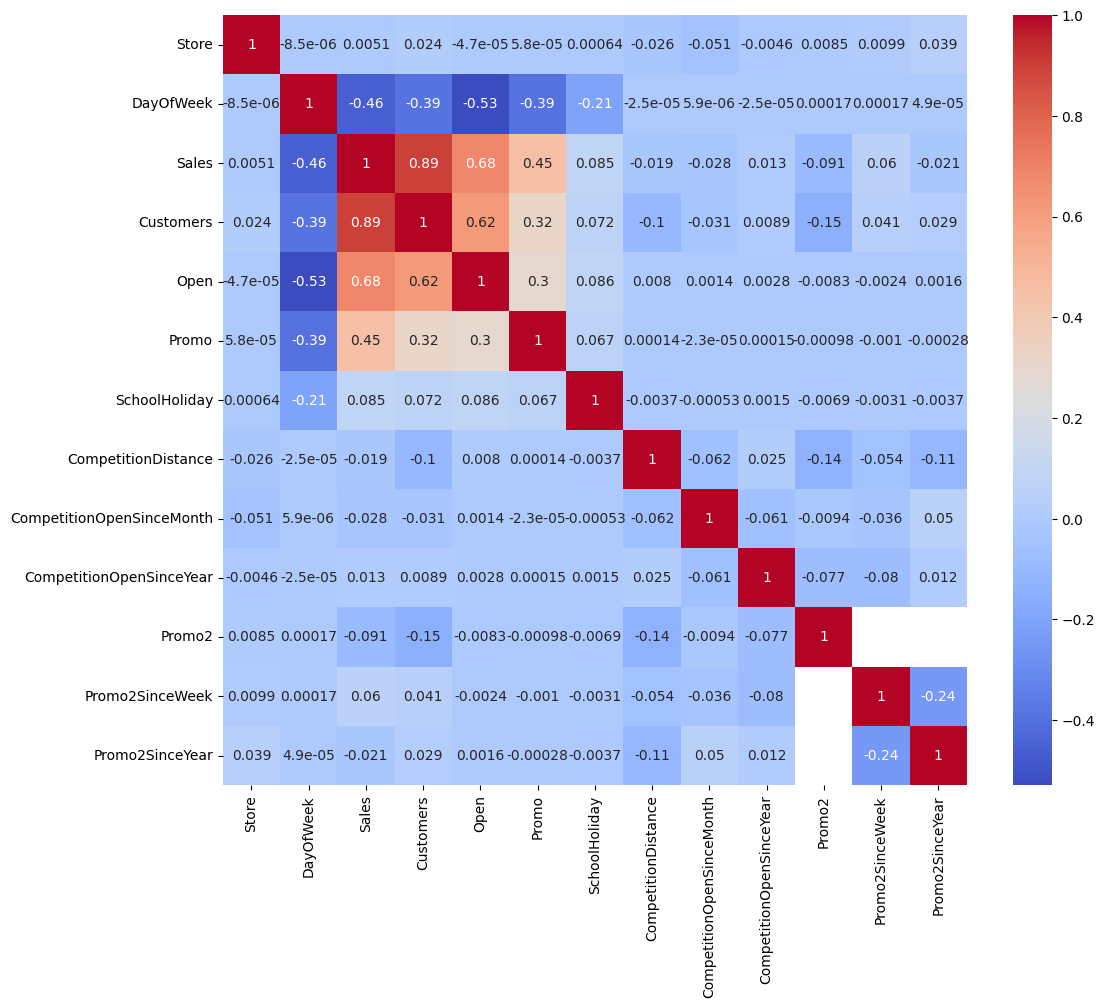

In [19]:
plt.figure(figsize=(12,10))

sns.heatmap(corr,annot=True,cmap='coolwarm')

In [20]:
for column in df.columns:
    print(f"Value counts for column '{column}':\n")
    print(df[column].value_counts())
    print("\n" + "-"*40 + "\n")

Value counts for column 'Store':

Store
1115    942
1       942
2       942
3       942
4       942
       ... 
1067    758
1080    758
22      758
20      758
13      758
Name: count, Length: 1115, dtype: int64

----------------------------------------

Value counts for column 'DayOfWeek':

DayOfWeek
5    145845
4    145845
3    145665
2    145664
1    144730
7    144730
6    144730
Name: count, dtype: int64

----------------------------------------

Value counts for column 'Date':

Date
2013-01-02    1115
2015-07-31    1115
2015-07-30    1115
2015-07-29    1115
2015-07-28    1115
              ... 
2014-12-12     935
2014-12-10     935
2014-12-09     935
2014-12-08     935
2014-12-07     935
Name: count, Length: 942, dtype: int64

----------------------------------------

Value counts for column 'Sales':

Sales
0        172871
5674        215
5558        197
5483        196
6214        195
          ...  
982           1
1173          1
1090          1
1338          1
18841         1

In [21]:
def generate_distribution_plot(df_train, continuous_features):
    data = df_train[continuous_features].copy()
    
    fig, axes = plt.subplots(nrows=len(data.columns)//2, ncols=2, figsize=(20, 20))
    fig.subplots_adjust(hspace=0.7)
    
    font = {'family': 'serif',
            'color':  'darkred',
            'weight': 'normal',
            'size': 16,
            }
    
    for ax, feature in zip(axes.flatten(), data.columns):
        feature_mean = data[feature].mean()
        feature_median = data[feature].median()
        feature_mode = data[feature].mode().values[0]
        
        sns.histplot(data[feature], ax=ax, kde=True)  # kde=True adds the KDE curve
        ax.set_title(f'Analysis of {feature}', fontdict=font)
        ax.axvline(feature_mean, color='r', linestyle='--', label="Mean")
        ax.axvline(feature_median, color='g', linestyle='-', label="Median")
        ax.axvline(feature_mode, color='b', linestyle='-', label="Mode")
        ax.legend()
    
    plt.show()

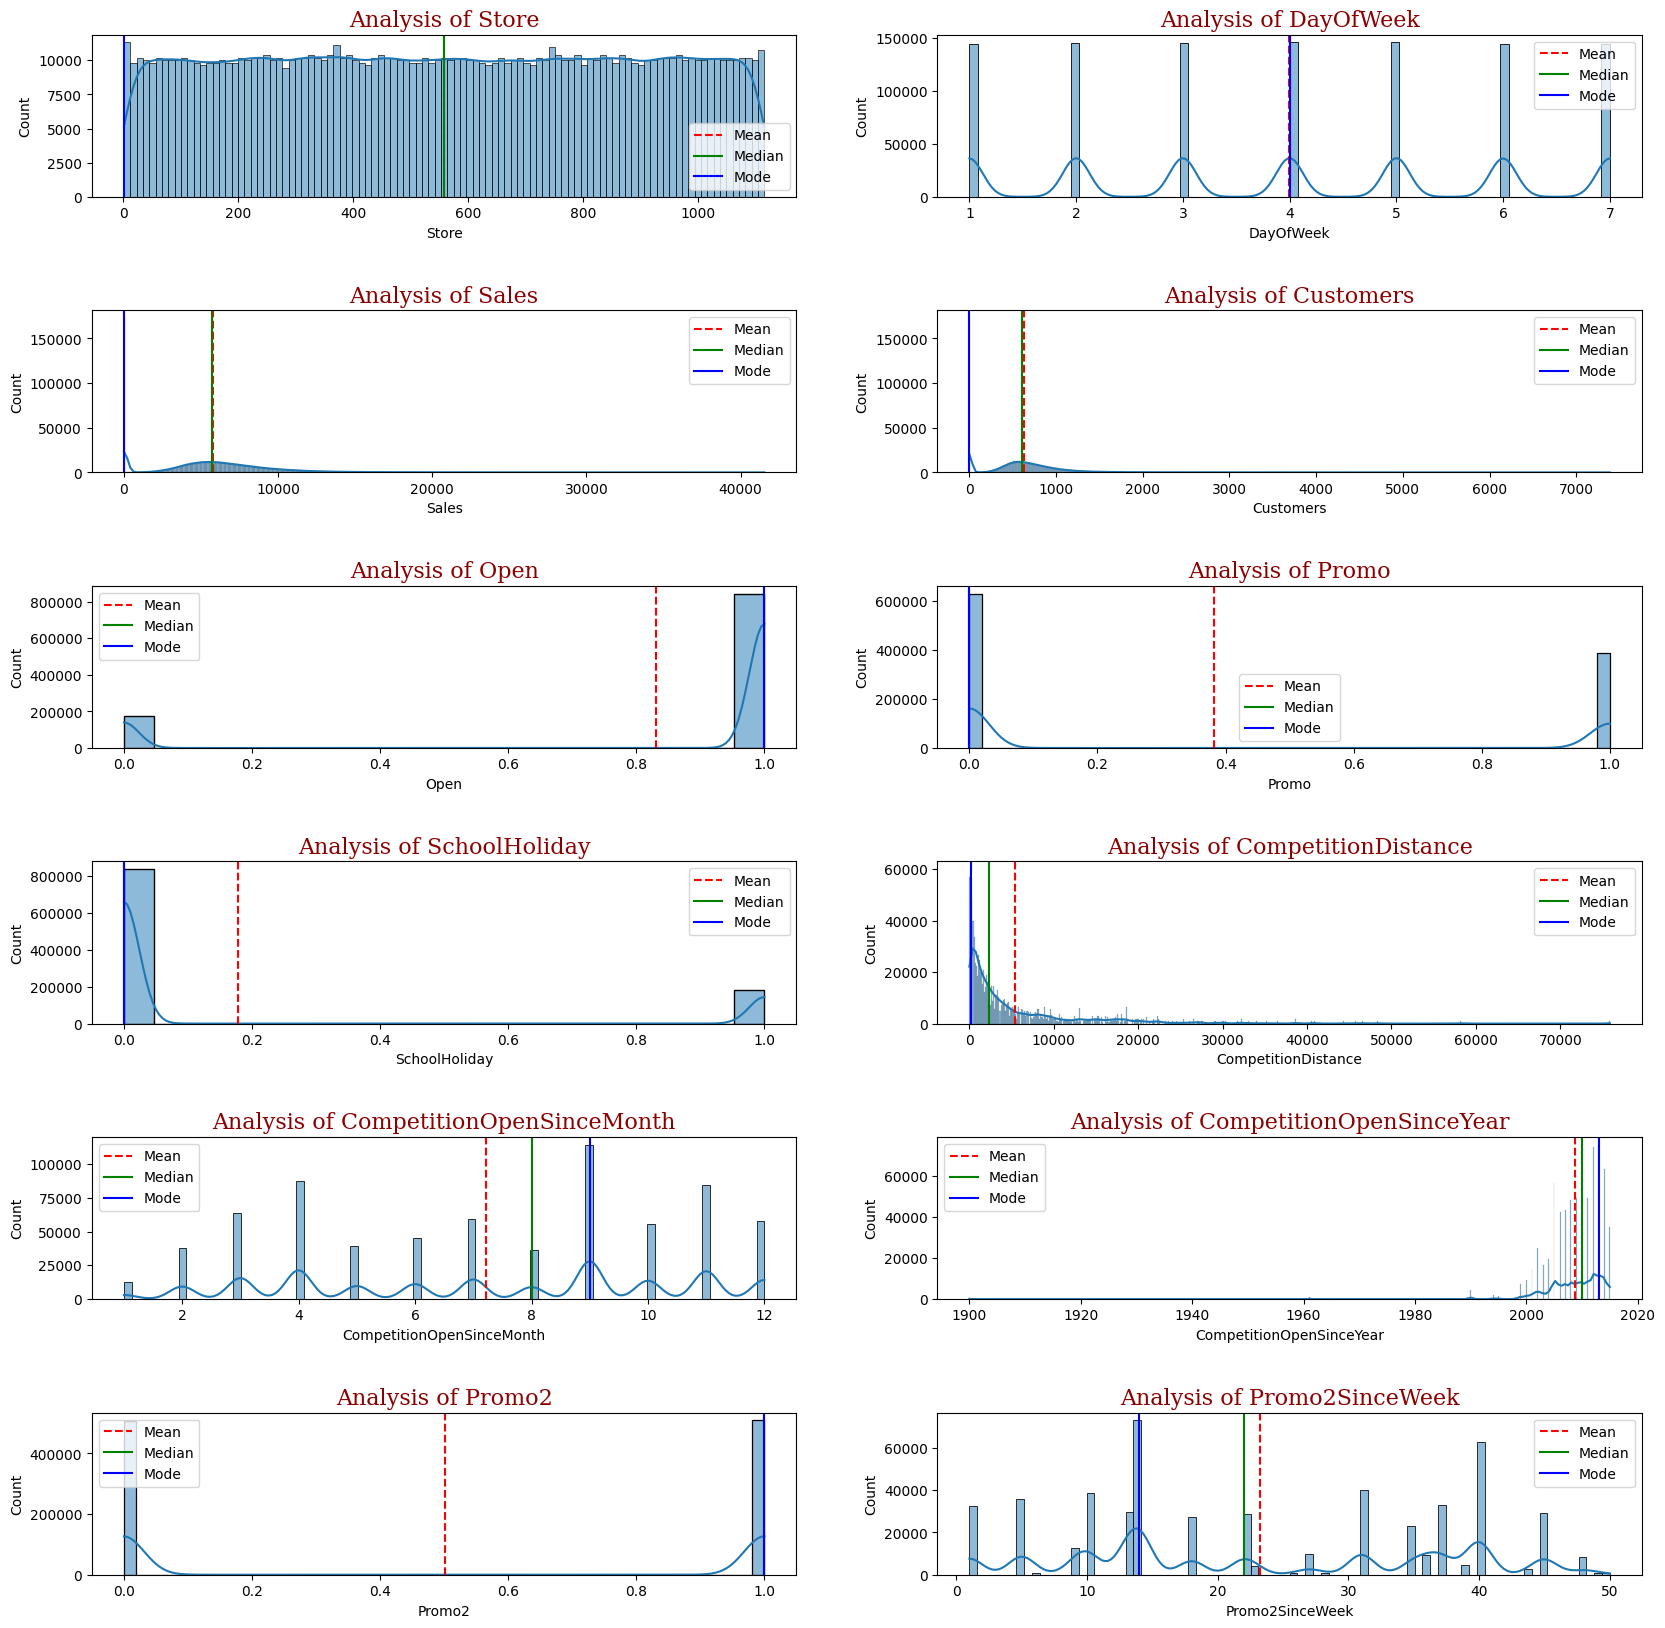

In [22]:
generate_distribution_plot(df, numerical_cols)

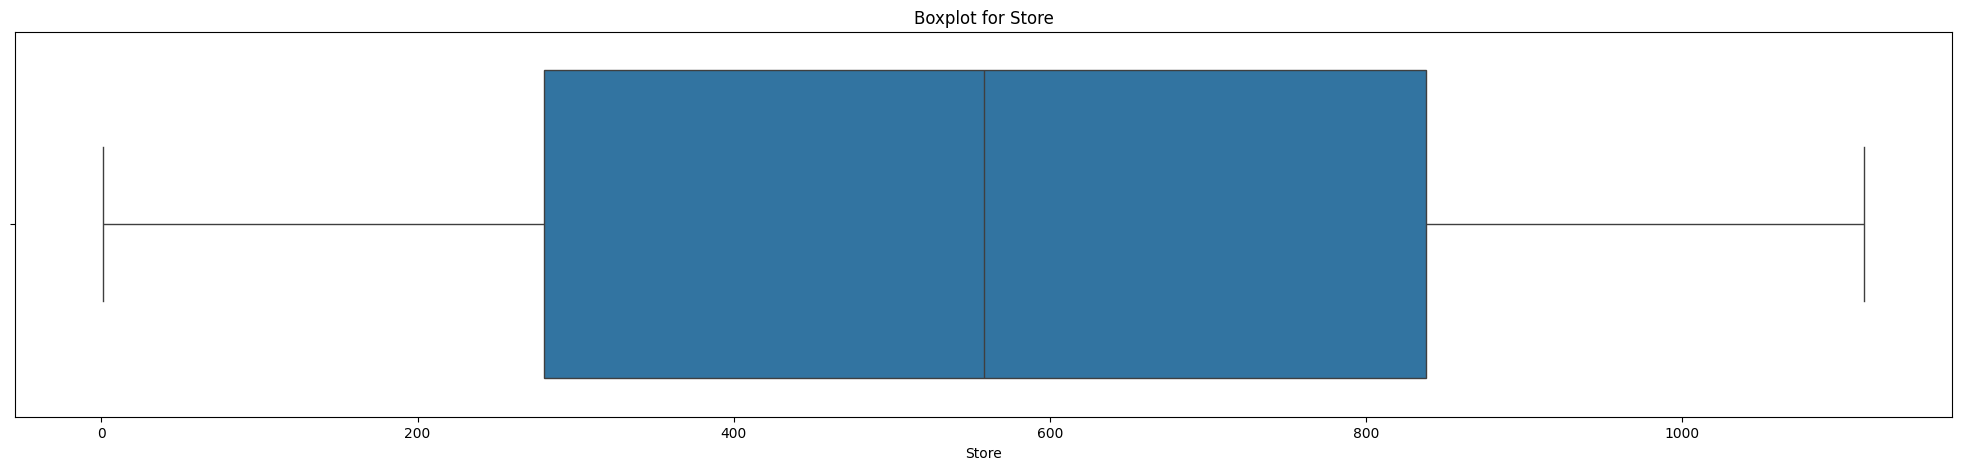

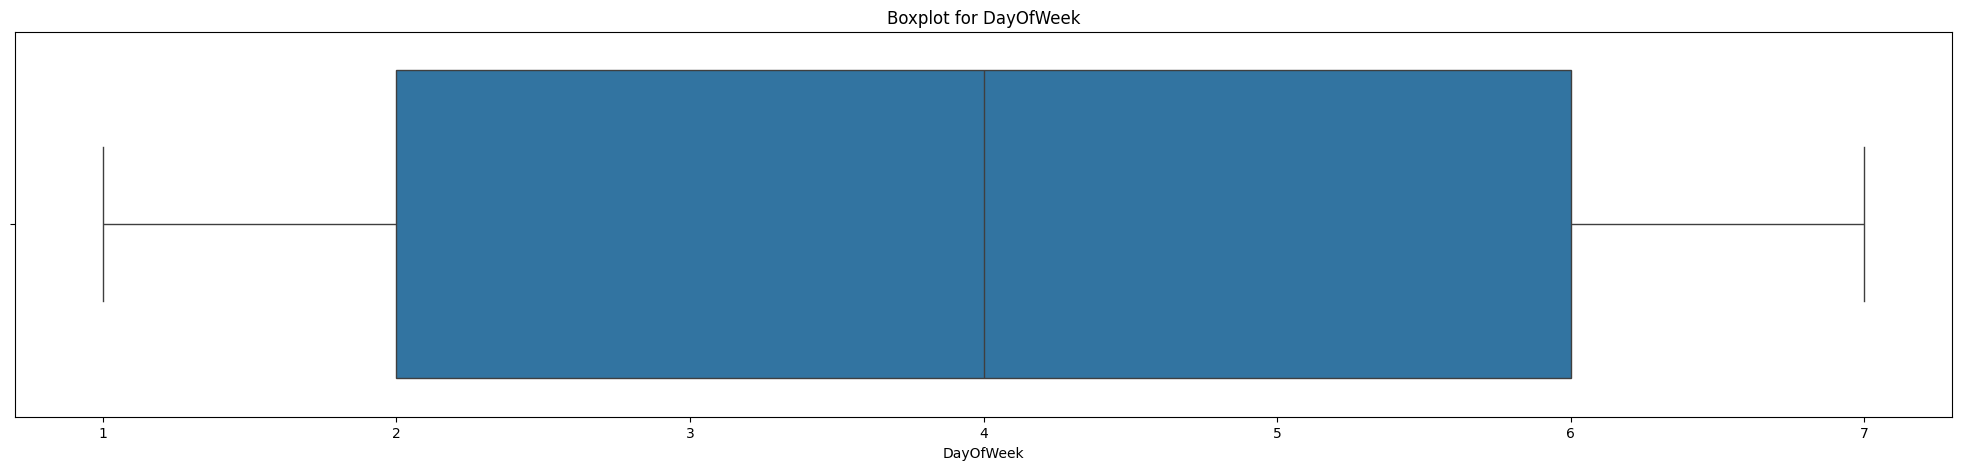

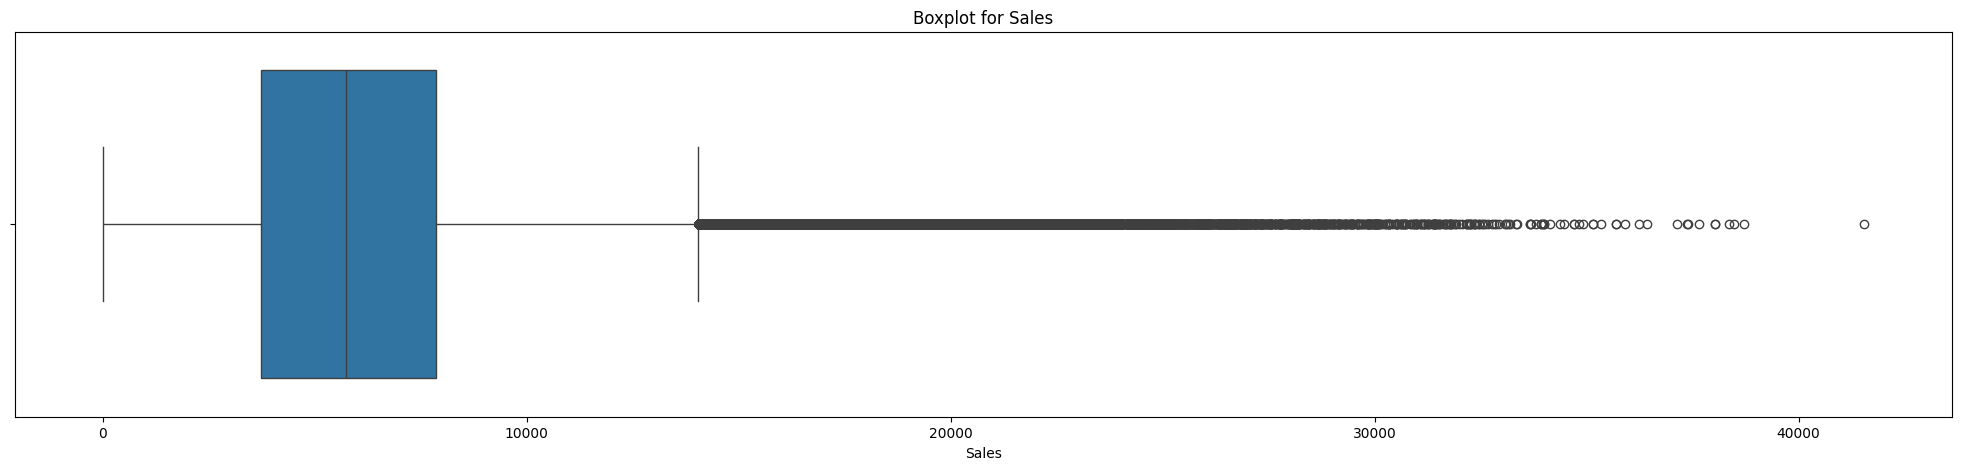

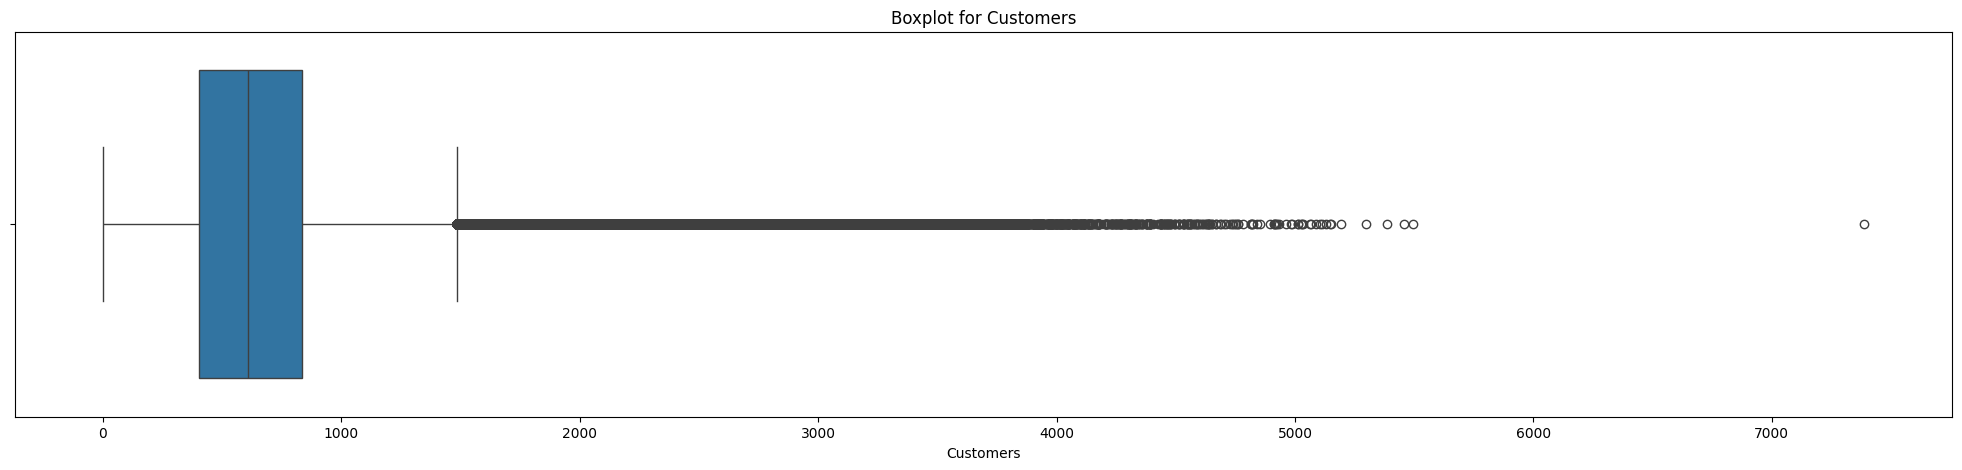

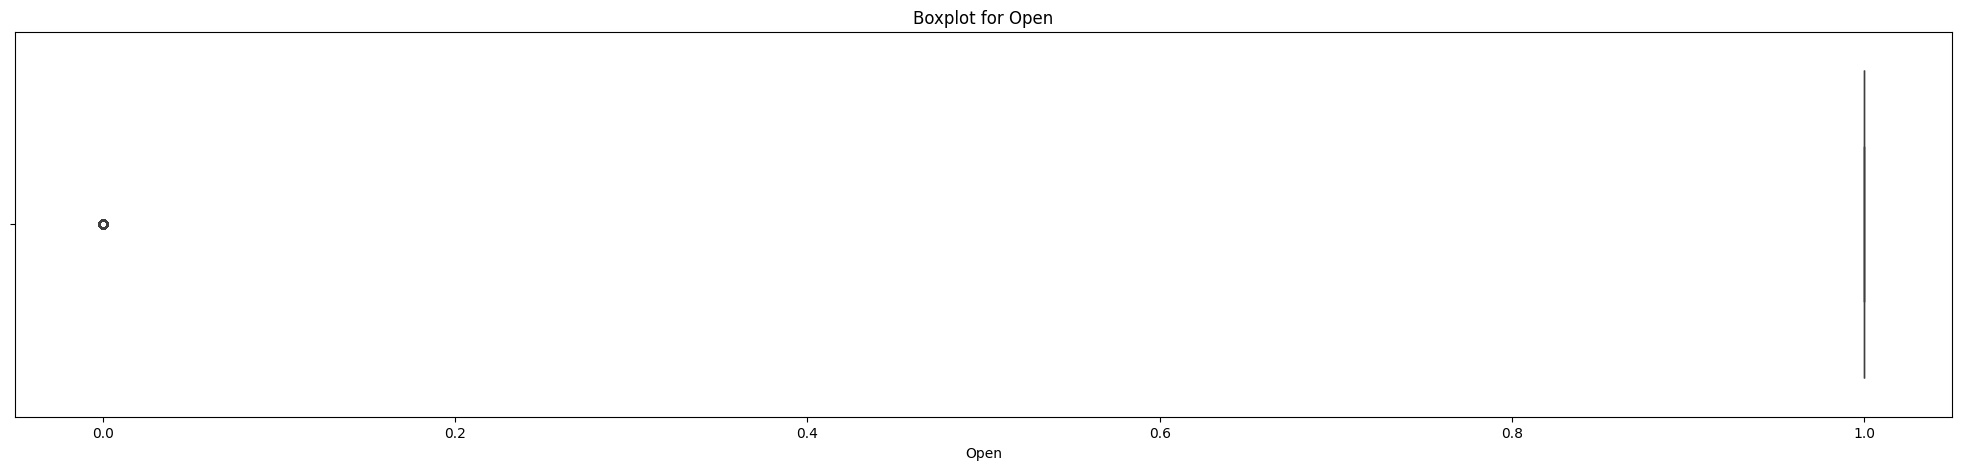

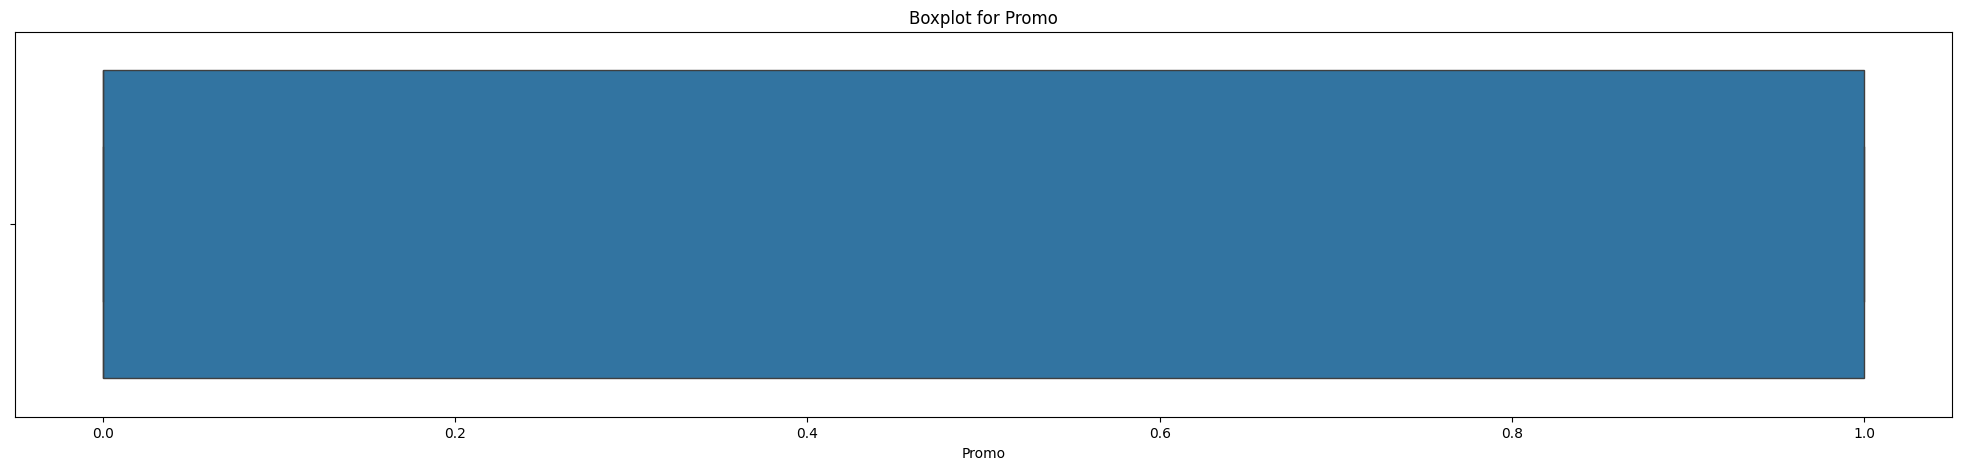

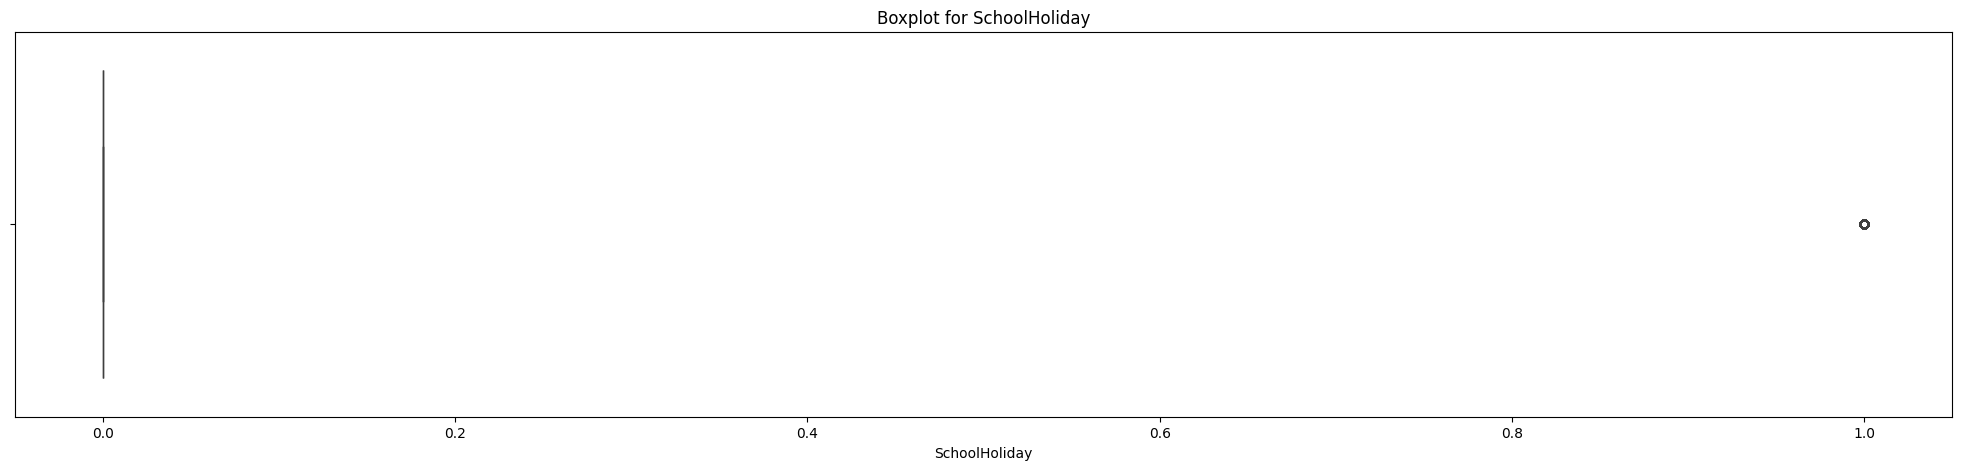

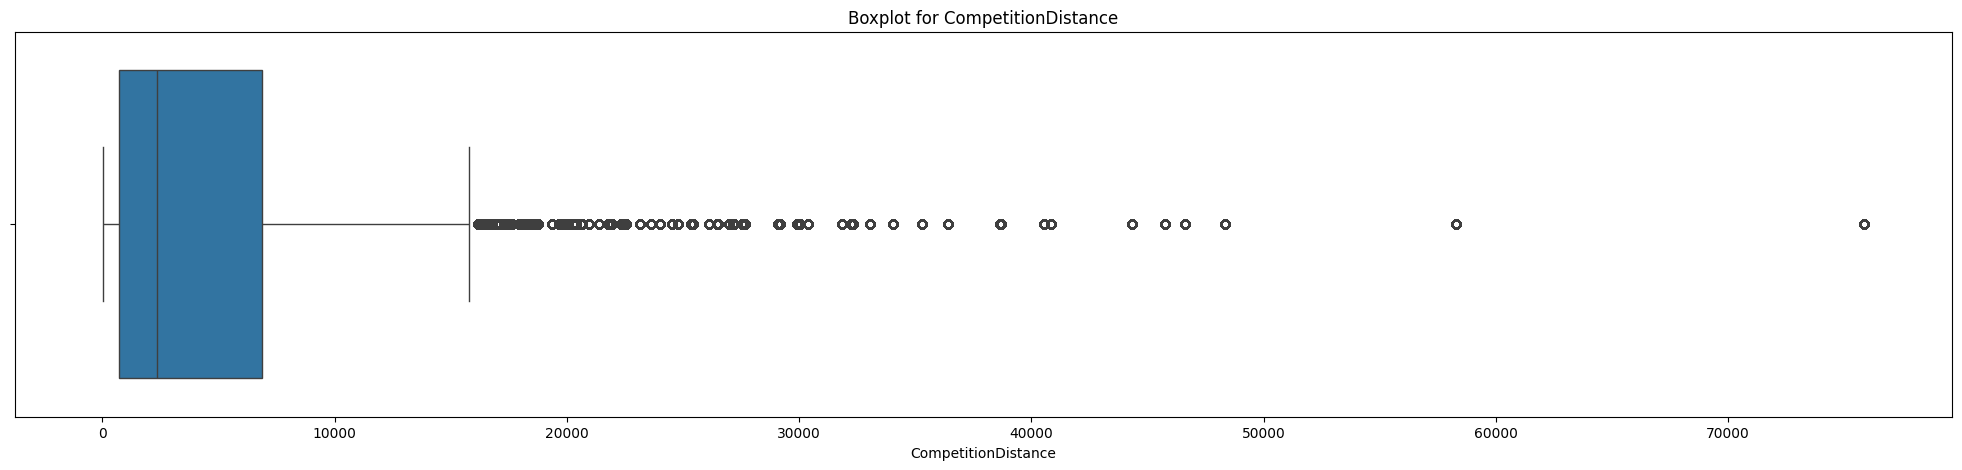

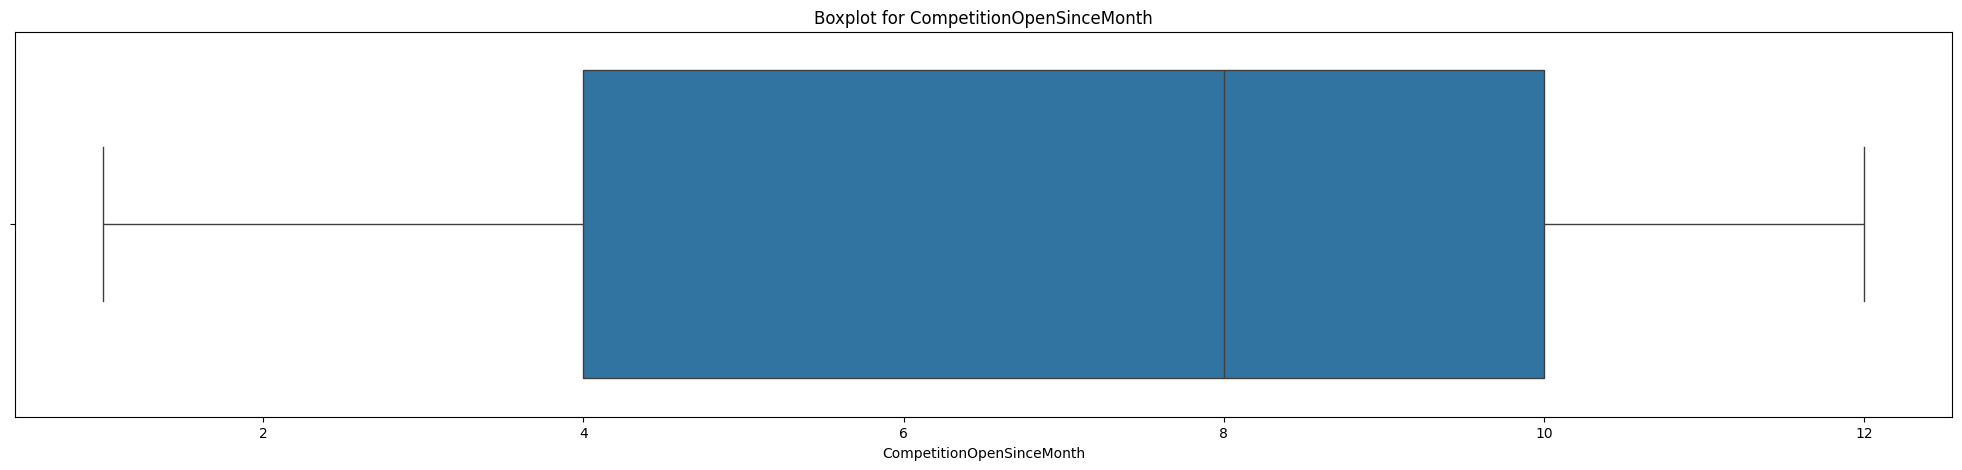

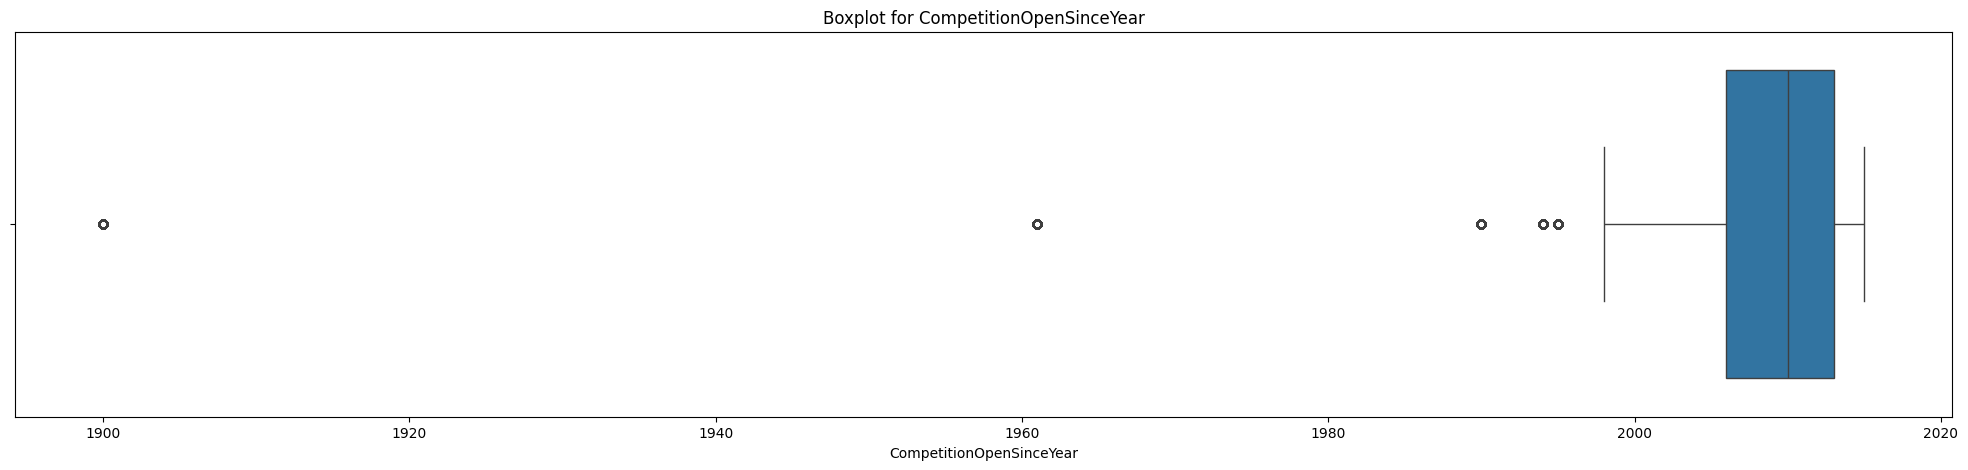

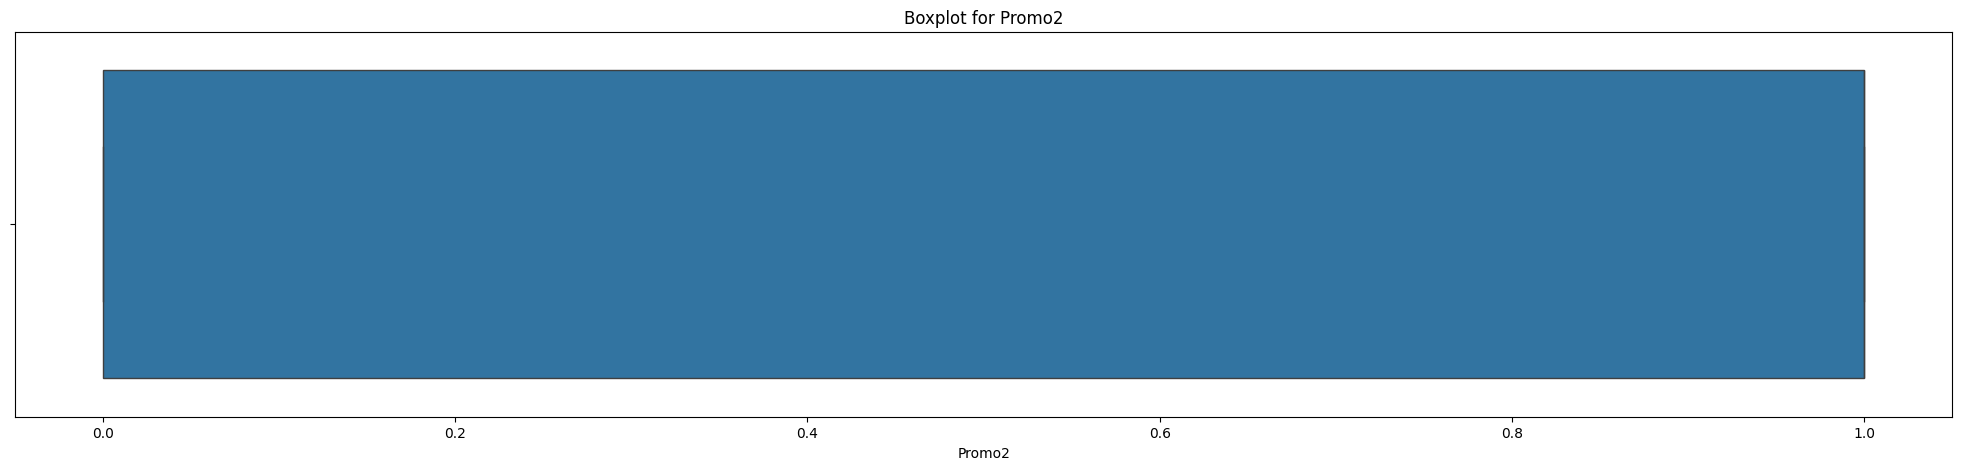

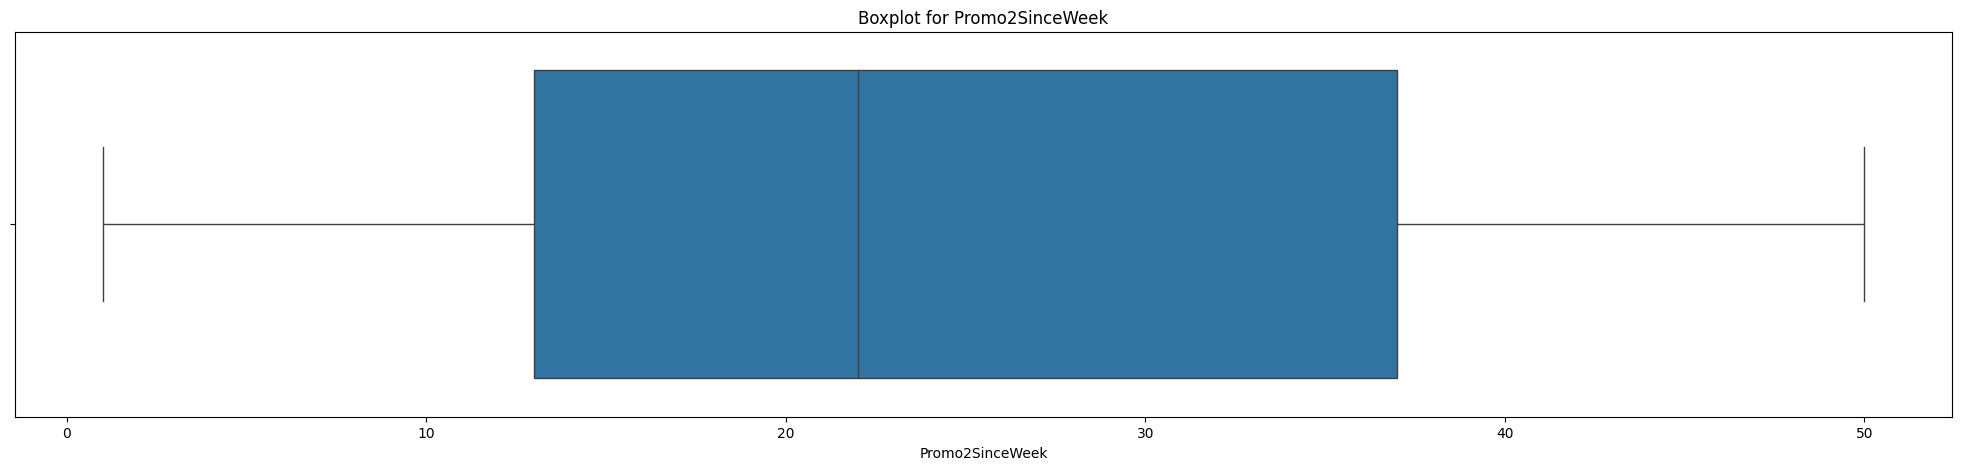

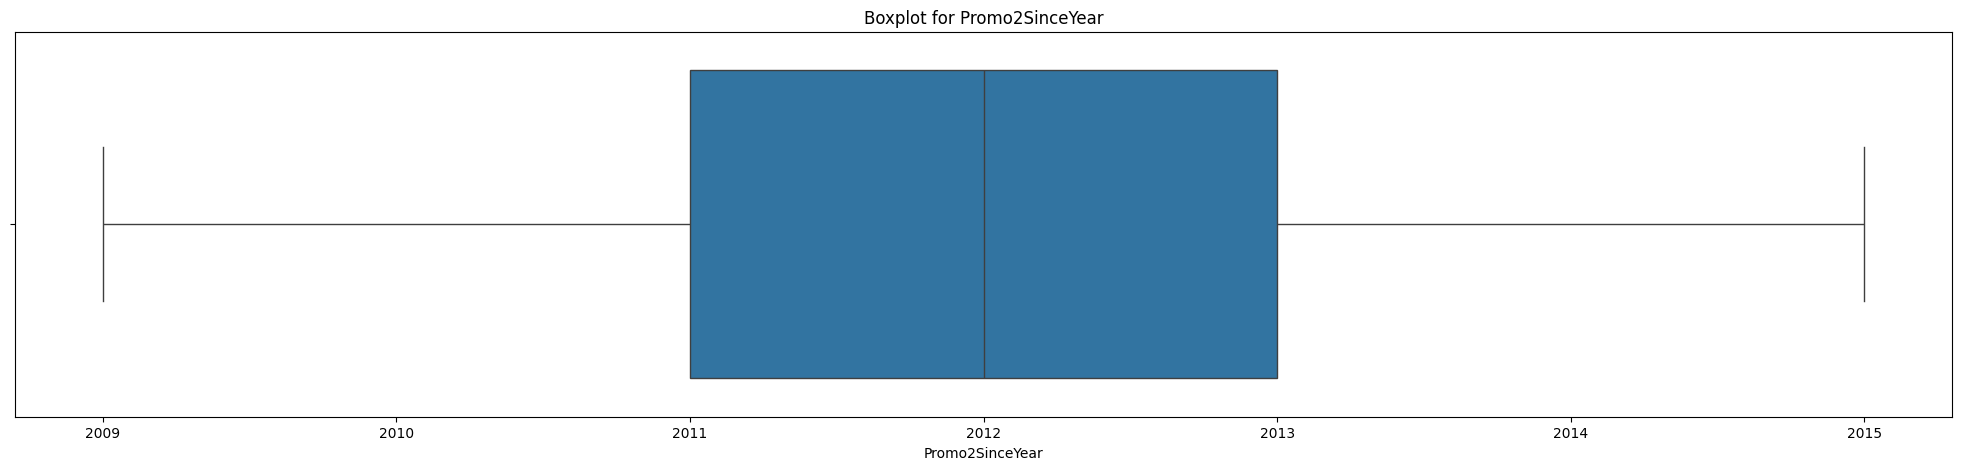

In [23]:
for i in df.select_dtypes(include=['number']).columns:
    plt.figure(figsize=(25, 5))  # Set the figure size
    sns.boxplot(x=df[i])
    plt.title(f'Boxplot for {i}')
    plt.show()


In [24]:
#check outliers
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Define outlier condition
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    # Print result
    print(f"Column: {col}")
    print(f"Number of outliers: {len(outliers)}")
    if len(outliers) > 0:
        print("Outlier values:")
        print(outliers[col].values[:10])  # Show first 10 outlier values
    else:
        print("No outliers detected.")
    print("-" * 40)


Column: Store
Number of outliers: 0
No outliers detected.
----------------------------------------
Column: DayOfWeek
Number of outliers: 0
No outliers detected.
----------------------------------------
Column: Sales
Number of outliers: 26694
Outlier values:
[15344 14190 14180 14949 14927 18227 16191 17286 22205 14096]
----------------------------------------
Column: Customers
Number of outliers: 38095
Outlier values:
[1498 1586 2041 1659 2508 2628 3669 2316 2592 2049]
----------------------------------------
Column: Open
Number of outliers: 172817
Outlier values:
[0 0 0 0 0 0 0 0 0 0]
----------------------------------------
Column: Promo
Number of outliers: 0
No outliers detected.
----------------------------------------
Column: SchoolHoliday
Number of outliers: 181721
Outlier values:
[1 1 1 1 1 1 1 1 1 1]
----------------------------------------
Column: CompetitionDistance
Number of outliers: 1014563
Outlier values:
[ 1270.   570. 14130.   620. 29910.   310.  2030.  3160.   960.  107

In [25]:
#corrolation sales with promotion , holiday

df_corr = df[['Sales', 'Promo', 'SchoolHoliday']].copy()

df_corr['SchoolHoliday'] = pd.to_numeric(df_corr['SchoolHoliday'], errors='coerce')
df_corr['Promo'] = pd.to_numeric(df_corr['Promo'], errors='coerce')
df_corr['Sales'] = pd.to_numeric(df_corr['Sales'], errors='coerce')

df_corr = df_corr.dropna()

correlation = df_corr.corr()

print("Correlation of Sales with Promo and SchoolHoliday:")
print(correlation['Sales'][['Promo', 'SchoolHoliday']])


Correlation of Sales with Promo and SchoolHoliday:
Promo            0.452345
SchoolHoliday    0.085124
Name: Sales, dtype: float64


In [26]:
#Grouped Averages (Categorical Patterns)

print("Average Sales by Promo:")
print(df.groupby('Promo')['Sales'].mean())


print("\nAverage Sales by DayOfWeek:")
print(df.groupby('DayOfWeek')['Sales'].mean())

print("\nAverage Sales by StoreType:")
print(df.groupby('StoreType')['Sales'].mean())


Average Sales by Promo:
Promo
0    4406.050805
1    7991.152046
Name: Sales, dtype: float64

Average Sales by DayOfWeek:
DayOfWeek
1    7809.044510
2    7005.244467
3    6555.884138
4    6247.575913
5    6723.274305
6    5847.562599
7     204.183189
Name: Sales, dtype: float64

Average Sales by StoreType:
StoreType
a     5738.179710
b    10058.837334
c     5723.629246
d     5641.819243
Name: Sales, dtype: float64


In [27]:
#Pivot Table (Multi-variable Pattern)

pivot = df.pivot_table(values='Sales', index='DayOfWeek', columns='Promo', aggfunc='mean')
print("\nSales Pattern by DayOfWeek and Promo:")
print(pivot)



Sales Pattern by DayOfWeek and Promo:
Promo                0            1
DayOfWeek                          
1          5604.357608  9707.808423
2          5612.048396  8227.909603
3          5418.548638  7554.021384
4          5097.574306  7259.497280
5          6178.610459  7202.540577
6          5847.562599          NaN
7           204.183189          NaN


# <p style="font-family:newtimeroman;font-size:130%;text-align:center;color:blue;"> Preprocessing</p>

# Handle Data Types

In [28]:
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Convert categorical features to category dtype
cat_cols = ['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval']
for col in cat_cols:
    df[col] = df[col].astype('category')


# Handle Missing Values

In [29]:
# Fill missing numeric values
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(df['CompetitionDistance'].median())
df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].fillna(0)
df['CompetitionOpenSinceYear'] = df['CompetitionOpenSinceYear'].fillna(0)

df['Promo2SinceWeek'] = df['Promo2SinceWeek'].fillna(0)
df['Promo2SinceYear'] = df['Promo2SinceYear'].fillna(0)

# Fix categorical column issue
if pd.api.types.is_categorical_dtype(df['PromoInterval']):
    # Add 'None' to categories if not already present
    if 'None' not in df['PromoInterval'].cat.categories:
        df['PromoInterval'] = df['PromoInterval'].cat.add_categories('None')
        
df['PromoInterval'] = df['PromoInterval'].fillna('None')

# Missing competition or promo info likely means “no data available” or “not applicable.”
#Replacing with 0 or 'None' prevents issues in ML models.

C:\Users\Yousif\AppData\Local\Temp\ipykernel_17260\899628571.py:10: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(df['PromoInterval']):


# Feature Engineering

In [30]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week
df['DayOfMonth'] = df['Date'].dt.day
df['IsMonthStart'] = df['Date'].dt.is_month_start.astype(int)
df['IsMonthEnd'] = df['Date'].dt.is_month_end.astype(int)
df['CompetitionAge'] = df['Year'] - df['CompetitionOpenSinceYear']
df['Promo2Duration'] = df['Year'] - df['Promo2SinceYear']

# Replace any negative or unrealistic durations with 0
df['CompetitionAge'] = df['CompetitionAge'].apply(lambda x: x if x > 0 else 0)
df['Promo2Duration'] = df['Promo2Duration'].apply(lambda x: x if x > 0 else 0)


# Drop Unnecessary Columns

In [31]:
# ✅ Columns to remove before encoding and modeling
cols_to_drop = [
    # 🔹 Identification & Redundant Columns
    'Store',            # ID-like column — not analytical, may cause overfitting
    'Date',             # Redundant — info already extracted into Month & Year

    # 🔹 Data Leakage / Target-related
    'Customers',        # Highly correlated with Sales (target variable)
    'Open',             # Used earlier to filter closed stores (Open=0)

    # 🔹 Low-value or messy columns
    'PromoInterval',    # Many missing values, adds little predictive value

    # 🔹 Original columns replaced by engineered ones
    'CompetitionOpenSinceMonth',
    'CompetitionOpenSinceYear',
    'Promo2SinceWeek',
    'Promo2SinceYear'
]

# Drop all unnecessary columns
df = df.drop(columns=cols_to_drop, errors='ignore')

# ✅ Confirmation
print("✅ All unnecessary columns removed successfully!")
print("Dropped columns:")
for col in cols_to_drop:
    print(f" - {col}")


✅ All unnecessary columns removed successfully!
Dropped columns:
 - Store
 - Date
 - Customers
 - Open
 - PromoInterval
 - CompetitionOpenSinceMonth
 - CompetitionOpenSinceYear
 - Promo2SinceWeek
 - Promo2SinceYear


# Handle Outliers

## 🧹 Outlier Treatment

This section identifies and treats **outliers** in the dataset to improve data quality and model performance.

---

### 📊 Outlier Summary

| Column | Number of Outliers | Interpretation | Recommended Action |
|:--------|:------------------:|:---------------|:------------------|
| **Store** | 0 | Store IDs are categorical numbers — no outliers expected. | ✅ No action needed |
| **DayOfWeek** | 0 | Days are from 1–7 — valid range. | ✅ No action needed |
| **Sales** | 26,694 | High sales spikes due to holidays or promotions. | ⚠️ Keep them (clip extreme ones if necessary). |
| **Customers** | 38,095 | High customer counts likely during promotions. | ⚠️ Keep or slightly clip extreme values. |
| **Open** | 172,817 | 0 indicates closed stores — valid data. | ✅ No action (consider filtering `Open=0`). |
| **Promo** | 0 | Valid binary values (0/1). | ✅ No action needed |
| **SchoolHoliday** | 181,721 | Indicates holidays — valid binary values. | ✅ No action needed |
| **CompetitionDistance** | 99,160 | Extremely large distances — potential skew. | ⚠️ Apply log transformation to reduce skewness. |
| **CompetitionOpenSinceMonth** | 0 | Values within 1–12 — valid. | ✅ No action needed |
| **CompetitionOpenSinceYear** | 9,994 | Unrealistic early years (e.g., 1900–1995). | ⚠️ Replace with median or most frequent year. |
| **Promo2** | 0 | Valid binary values (0/1). | ✅ No action needed |
| **Promo2SinceWeek** | 0 | Valid week numbers. | ✅ No action needed |
| **Promo2SinceYear** | 0 | Valid years. | ✅ No action needed |
| **Month** | 0 | Values between 1–12 — valid. | ✅ No action needed |

---

### 🧠 Insights

- Outliers in **Sales** and **Customers** represent special events or holidays — they’re informative, not errors.  
- Outliers in **CompetitionDistance** and **CompetitionOpenSinceYear** can distort model training.  
- Binary columns like `Open` and `SchoolHoliday` should remain untouched.

---



In [32]:
# ✅ 1️⃣ Function: Treat general outliers using IQR
def treat_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data[column] = np.where(
        data[column] > upper, upper,
        np.where(data[column] < lower, lower, data[column])
    )
    return data


# ✅ 2️⃣ Apply IQR treatment to numeric columns (excluding ID-like columns)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    if col not in ['Store', 'Customers', 'Open']:
        df = treat_outliers_iqr(df, col)


# ✅ 3️⃣ Log-transform CompetitionDistance (only if it exists)
if 'CompetitionDistance' in df.columns:
    df['CompetitionDistance'] = np.log1p(df['CompetitionDistance'])


# ✅ 4️⃣ Clip extreme values for key metrics (Sales only, since Customers was dropped)
def clip_outliers(df, col):
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower, upper)
    return df

if 'Sales' in df.columns:
    df = clip_outliers(df, 'Sales')


# ✅ 5️⃣ Remove closed stores step removed (since 'Open' column was dropped)


# ✅ 6️⃣ Summary
print("✅ Outlier Treatment Completed Successfully!")
print(f"Remaining Rows: {df.shape[0]}")
print(f"Columns Processed (excluding dropped ones): {len(num_cols)}")


✅ Outlier Treatment Completed Successfully!
Remaining Rows: 1017209
Columns Processed (excluding dropped ones): 10


# Encode Categorical Columns

In [33]:
df = pd.get_dummies(df, drop_first=True)

# FEATURE SELECTION 

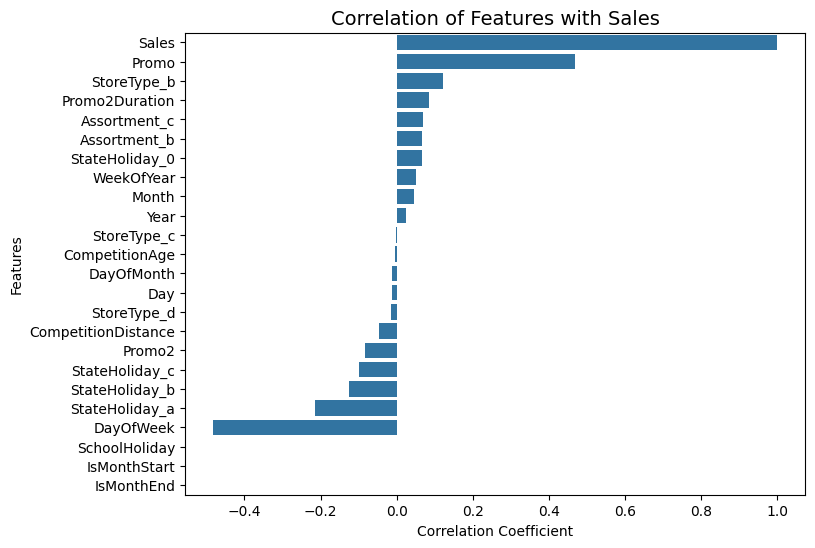

✅ Selected 12 features based on correlation threshold 0.05:
['Promo', 'StoreType_b', 'Promo2Duration', 'Assortment_c', 'Assortment_b', 'StateHoliday_0', 'WeekOfYear', 'Promo2', 'StateHoliday_c', 'StateHoliday_b', 'StateHoliday_a', 'DayOfWeek']


In [34]:

# 1️⃣ Compute correlation matrix
corr_matrix = df.corr()

# 2️⃣ Visualize correlation with target (e.g., 'Sales')
plt.figure(figsize=(8, 6))
corr_with_target = corr_matrix['Sales'].sort_values(ascending=False)
sns.barplot(x=corr_with_target.values, y=corr_with_target.index)
plt.title('Correlation of Features with Sales', fontsize=14)
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.show()

# 3️⃣ Select highly correlated features (based on a threshold)
threshold = 0.05  # يمكنك تعديله (مثلاً 0.1 لو عايز أعمدة أقوى فقط)
selected_features = corr_with_target[abs(corr_with_target) > threshold].index.tolist()

# 4️⃣ Drop the target variable if included
if 'Sales' in selected_features:
    selected_features.remove('Sales')

# 5️⃣ Keep only selected features
df = df[selected_features + ['Sales']]  # احتفظ بالـ target
print(f"✅ Selected {len(selected_features)} features based on correlation threshold {threshold}:")
print(selected_features)


# Define Features and Target


In [35]:
X = df.drop("Sales", axis=1)
y = df["Sales"]

# Split Data into Train/Test


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale Numerical Features

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [38]:
X_train

array([[-7.85312004e-01, -1.25513676e-01, -9.97423822e-01, ...,
        -8.13579553e-02, -1.42321776e-01,  1.50336285e+00],
       [-7.85312004e-01, -1.25513676e-01,  1.00075035e+00, ...,
        -8.13579553e-02, -1.42321776e-01,  1.50336285e+00],
       [-7.85312004e-01, -1.25513676e-01,  1.00075035e+00, ...,
        -8.13579553e-02, -1.42321776e-01,  5.01980696e-01],
       ...,
       [-7.85312004e-01, -1.25513676e-01,  1.00273858e+00, ...,
        -8.13579553e-02, -1.42321776e-01,  1.00267177e+00],
       [ 1.27337924e+00, -1.25513676e-01, -9.97423822e-01, ...,
        -8.13579553e-02, -1.42321776e-01,  1.28961791e-03],
       [ 1.27337924e+00, -1.25513676e-01, -9.96429705e-01, ...,
        -8.13579553e-02, -1.42321776e-01, -1.50078362e+00]],
      shape=(813767, 12))

In [39]:
X_test

array([[-0.785312  , -0.12551368, -0.99543559, ..., -0.08135796,
        -0.14232178,  1.50336285],
       [ 1.27337924, -0.12551368,  1.00075035, ..., -0.08135796,
        -0.14232178, -1.00009254],
       [-0.785312  , -0.12551368, -0.99841794, ..., -0.08135796,
        -0.14232178,  1.00267177],
       ...,
       [-0.785312  , -0.12551368, -0.99642971, ..., -0.08135796,
        -0.14232178,  1.00267177],
       [-0.785312  , -0.12551368, -0.99841794, ..., -0.08135796,
        -0.14232178,  1.50336285],
       [-0.785312  , -0.12551368,  1.00174446, ..., -0.08135796,
        -0.14232178,  1.00267177]], shape=(203442, 12))

In [61]:

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, AdaBoostRegressor, BaggingRegressor
from xgboost import XGBRegressor

from sklearn.ensemble import HistGradientBoostingRegressor

#Evaluation
from sklearn.metrics import r2_score

# Pipeline & utilities
import joblib
import os

In [62]:
def train_model(x_train, y_train):
    trained_models = {}
    for name, model in REGRESSION_MODELS.items():
        print(f"Training {name}")
        trained_models[name] = model.fit(x_train, y_train)

    print("Model has been trained")
    return trained_models

In [63]:

def evaluate_all_models(trained_models, X, y, dataset_name):

    scores = {}
    print(f"\n{'='*60}")
    print(f"Evaluating models on {dataset_name} dataset:")
    print(f"{'='*60}")

    for name, model in trained_models.items():
        y_pred = model.predict(X)
        score = r2_score(y, y_pred)
        scores[name] = score
        print(f"R² score for {name}: {(score * 100):.4f}%")

    print(f"{'='*60}")
    return scores

In [64]:
def load_model(path):
    if os.path.exists(path):
        print("Model has been loaded")
        return joblib.load(path)
    else:
        raise FileNotFoundError(f"No model found at {path}")

In [65]:
def save_model(model, path):
    joblib.dump(model, path)
    print(f"Model has been saved")

In [66]:
"""Constants"""
MODEL_PATH = "test.plk"
DATA_PATH = df
TARGET = "Sales"
TEST_SIZE = 0.2
RANDOM_STATE = 42

auto_select_numerical = True
auto_select_categorical = True
NUMERICAL_FEATURES = []
CATEGORICAL_FEATURES = []

decision_tree_estimator = DecisionTreeRegressor(random_state=RANDOM_STATE)

REGRESSION_MODELS = {
    "LinearRegression": LinearRegression(),
    # "KNN": KNeighborsRegressor(n_neighbors=5),
    # "SVR_rbf": SVR(kernel="rbf", C=1.0, epsilon=0.1),
    # "SVR_linear": SVR(kernel="linear", C=1.0, epsilon=0.1),
    # "SVR_poly": SVR(kernel="poly", C=1.0, epsilon=0.1),
    # "SVR_sigmoid": SVR(kernel="sigmoid", C=1.0, epsilon=0.1),
    "DecisionTree": DecisionTreeRegressor(random_state=RANDOM_STATE , max_depth=5),
    # "RandomForest": RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE),
    # "Bagging": BaggingRegressor(estimator=decision_tree_estimator, n_estimators=50, random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostRegressor(estimator=decision_tree_estimator, n_estimators=50, learning_rate=0.1, random_state=RANDOM_STATE),
    # "GradientBoosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=RANDOM_STATE),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=RANDOM_STATE),
}

In [67]:
def run_pipeline():
    


    # Train all models
    trained_models = train_model(X_train, y_train)

    # Evaluate on Training set (R²)
    print("\n--- Training Set Performance ---")
    train_scores = {}
    for name, model in trained_models.items():
        y_pred_train = model.predict(X_train)
        score_train = r2_score(y_train, y_pred_train)
        train_scores[name] = score_train
        print(f"{name} R² on Training set = {score_train*100:.2f}%")

    # Evaluate on Test set (R²)
    print("\n--- Test Set Performance ---")
    test_scores = {}
    for name, model in trained_models.items():
        y_pred_test = model.predict(X_test)
        score_test = r2_score(y_test, y_pred_test)
        test_scores[name] = score_test
        print(f"{name} R² on Test set = {score_test*100:.2f}%")

    # Select best model based on Test set
    best_model_name = max(test_scores, key=test_scores.get)
    best_model = trained_models[best_model_name]
    print(f"\nBest model based on Test set: {best_model_name} with R² = {test_scores[best_model_name]*100:.2f}%")

  
    save_model(best_model, MODEL_PATH)

In [69]:
# ############################################test 

from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor, HistGradientBoostingRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

REGRESSION_MODELS = {
    "LinearRegression": LinearRegression(),

    # Regularized linear models (سريعة جدًا)
    "Lasso": Lasso(alpha=0.001),
    "Ridge": Ridge(alpha=1.0),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5),

    # Tree models
    "DecisionTree": DecisionTreeRegressor(random_state=42, max_depth=5),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=200, random_state=42),

    # Boosting models (سريعة + قوية)
    "AdaBoost": AdaBoostRegressor(
        estimator=decision_tree_estimator,
        n_estimators=50,
        learning_rate=0.1,
        random_state=RANDOM_STATE
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42),

    # Top-performing models
    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE
    ),

    "CatBoost": CatBoostRegressor(
        depth=6,
        learning_rate=0.05,
        iterations=300,
        verbose=False,
        random_state=RANDOM_STATE
    ),
}


In [70]:
run_pipeline()

Training LinearRegression
Training Lasso


C:\Users\Yousif\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.863e+12, tolerance: 1.053e+09
  model = cd_fast.enet_coordinate_descent(


Training Ridge
Training ElasticNet


C:\Users\Yousif\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.814e+12, tolerance: 1.053e+09
  model = cd_fast.enet_coordinate_descent(


Training DecisionTree
Training ExtraTrees
Training AdaBoost
Training HistGradientBoosting
Training XGBoost
Training LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023350 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 99
[LightGBM] [Info] Number of data points in the train set: 813767, number of used features: 12
[LightGBM] [Info] Start training from score 5691.536080
Training CatBoost
Model has been trained

--- Training Set Performance ---
LinearRegression R² on Training set = 43.57%
Lasso R² on Training set = 43.57%
Ridge R² on Training set = 43.57%
ElasticNet R² on Training set = 43.57%
DecisionTree R² on Training set = 59.81%
ExtraTrees R² on Training set = 67.38%
AdaBoost R² on Training set = 66.07%
HistGradientBoosting R² on Training set = 66.24%
XGBoost R² on Training set = 65.97%


C:\Users\Yousif\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM R² on Training set = 66.47%
CatBoost R² on Training set = 65.60%

--- Test Set Performance ---
LinearRegression R² on Test set = 43.45%
Lasso R² on Test set = 43.45%
Ridge R² on Test set = 43.45%
ElasticNet R² on Test set = 43.45%
DecisionTree R² on Test set = 59.86%
ExtraTrees R² on Test set = 66.03%
AdaBoost R² on Test set = 64.63%
HistGradientBoosting R² on Test set = 66.18%
XGBoost R² on Test set = 65.94%


C:\Users\Yousif\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM R² on Test set = 66.38%
CatBoost R² on Test set = 65.59%

Best model based on Test set: LightGBM with R² = 66.38%
Model has been saved


In [73]:
import joblib
import json
from sklearn.ensemble import HistGradientBoostingRegressor

# 1. التأكد من أن X_train و y_train جاهزين (بعد الـ Scaling والـ Encoding)
# استخدام HistGradientBoosting لأنه الأسرع والأدق للداتا الكبيرة
model = HistGradientBoostingRegressor(random_state=42)
print("Training Model...")
model.fit(X_train, y_train)
print("Training Done!")

# 2. حفظ الموديل
joblib.dump(model, 'sales_model.pkl')

# 3. حفظ الـ Scaler (المستخدم في الخلية 42)
joblib.dump(scaler, 'scaler.pkl')

# 4. حفظ أسماء الأعمدة النهائية (مهم جداً عشان الـ One Hot Encoding في الموقع)
# X هي الداتا بعد ما عملت get_dummies وقبل ما تعمل scaling
model_columns = list(X.columns)
with open('model_columns.json', 'w') as f:
    json.dump(model_columns, f)

print("✅ تم حفظ الملفات بنجاح: sales_model.pkl, scaler.pkl, model_columns.json")


Training Model...
Training Done!
✅ تم حفظ الملفات بنجاح: sales_model.pkl, scaler.pkl, model_columns.json
